In [1]:
import time
import random
import math
import matplotlib.pyplot as plt

In [97]:
def generate_probabilistic_triplet(bit_length):
    triplet = []
    lower_bound = 2**(bit_length - 1)
    upper_bound = 2**bit_length - 1
    
    while len(triplet) < 3:
        candidate = random.randint(lower_bound, upper_bound)
        if all(math.gcd(candidate, x) == 1 for x in triplet):
            triplet.append(candidate)
    return triplet

def p_adic_valuation(n, p):
    if n == 0: return float('inf')
    k = 0
    while n % p == 0:
        k += 1
        n //= p
    return k

def generate_deterministic_triplet(N, p):
    valuation = p_adic_valuation(N, p)
    A = N // (p ** valuation)
    return [A - p, A, A + p]

def run_benchmark(iterations, bit_length):
    prob_times = []
    det_times = []
    
    p = 3
    print(f"iterations: {iterations} \nbits: {bit_length}")
    
    for _ in range(iterations):
        start_time = time.perf_counter()
        generate_probabilistic_triplet(bit_length)
        prob_times.append(time.perf_counter() - start_time)
        N = random.randint(2**(bit_length-1), 2**bit_length - 1)
        if N % 2!= 0: N -= 1
        start_time = time.perf_counter()
        generate_deterministic_triplet(N, p)
        det_times.append(time.perf_counter() - start_time)
        
    return prob_times, det_times

def plot_results(prob_times, det_times):
    plt.figure(figsize=(10, 5))
    plt.plot(prob_times, label='Probabilistic (Rejection Sampling)', color='red', alpha=0.7, linewidth=1.5)
    plt.plot(det_times, label='Deterministic (p-adic O(1))', color='blue', alpha=0.9, linewidth=2)
    plt.title("Execution Time: Probabilistic vs. Deterministic Coprime Set Generation", fontsize=14)
    plt.xlabel("Iteration", fontsize=12)
    plt.ylabel("Time (seconds)", fontsize=12)
    plt.legend(loc="upper right")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('benchmark_results.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
p_times, d_times = run_benchmark(iterations=500, bit_length=1024)
plot_results(p_times, d_times)

In [69]:
import networkx as nx

In [76]:
def generate_padic_tree():
    G = nx.DiGraph()
    G.add_node(0)
    
    level_1 = [1, 2, 3]
    for node in level_1:
        G.add_edge(0, node)
        
    for node in [4, 7, 10]: G.add_edge(1, node)
    for node in [5, 8, 11]: G.add_edge(2, node)
    for node in [6, 9, 12]: G.add_edge(3, node)

    pos = {
        0: (0, 2),
        1: (-2, 1), 2: (0, 1), 3: (2, 1),
        4: (-2.6, 0), 7: (-2.0, 0), 10: (-1.4, 0),
        5: (-0.6, 0), 8: (0, 0), 11: (0.6, 0),
        6: (1.4, 0), 9: (2.0, 0), 12: (2.6, 0)
    }

    plt.figure(figsize=(10, 6))
    nx.draw(G, pos, with_labels=True, node_size=1500, node_color="#e0e7ff", 
            edge_color="#475569", width=1.5, font_size=12, font_weight="bold", 
            arrows=True, arrowstyle="-|>", arrowsize=15)
    plt.title("Figure 1: A visual diagram of how integers branch out based on their divisibility.\nThis turns abstract p-adic metrics into a tree data structure. Integers highly divisible by $p$ travel deeper down specific branches)", fontsize=14, pad=20)
    plt.tight_layout()
    plt.savefig("padic_tree.png", dpi=300, bbox_inches="tight")
    plt.show()

/tmp/ipykernel_2771/2721609983.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


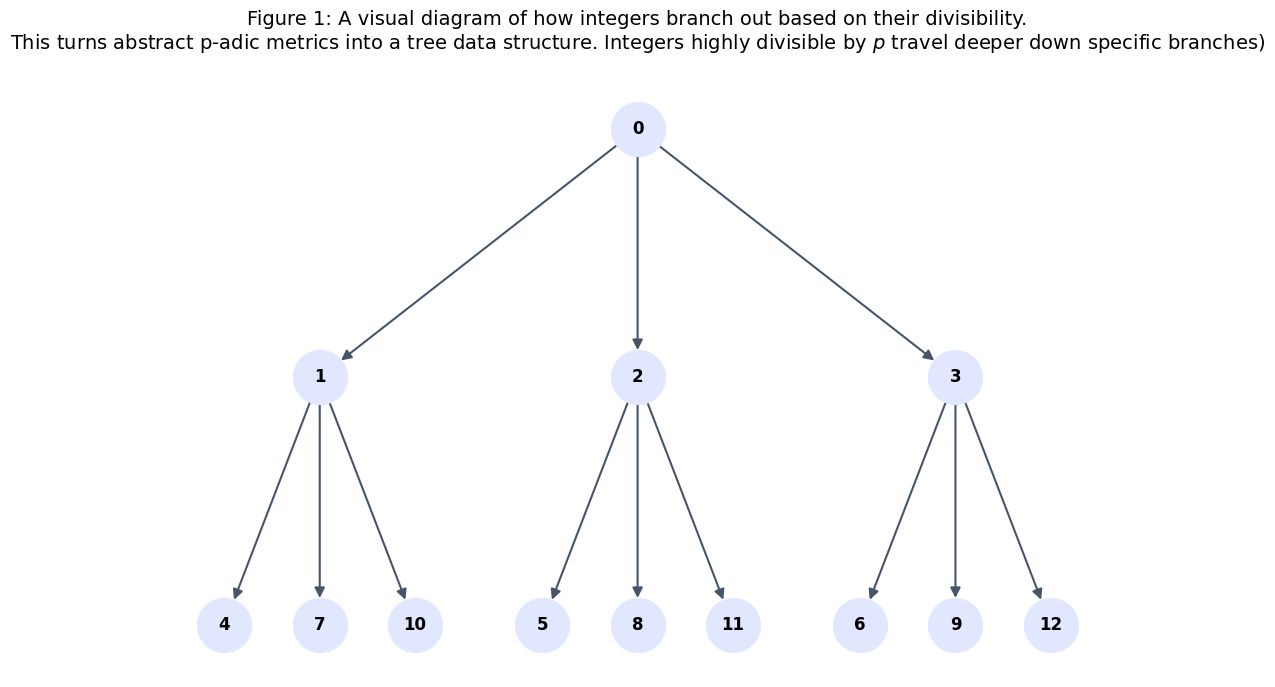

In [77]:
generate_padic_tree()

In [91]:
def generate_probabilistic_triplet(bit_length):
    triplet = []
    lower_bound = 2**(bit_length - 1)
    upper_bound = 2**bit_length - 1
    
    iterations = 0
    while len(triplet) < 3:
        iterations += 1
        candidate = random.randint(lower_bound, upper_bound)
        if all(math.gcd(candidate, x) == 1 for x in triplet):
            triplet.append(candidate)
            
    return iterations

def run_iteration_benchmark(test_runs, bit_length):
    prob_iterations = []
    det_iterations = []
    
    for _ in range(test_runs):
        prob_iterations.append(generate_probabilistic_triplet(bit_length))
        det_iterations.append(1) 
        
    return prob_iterations, det_iterations


In [92]:
p_iters, d_iters = run_iteration_benchmark(500, 1024)

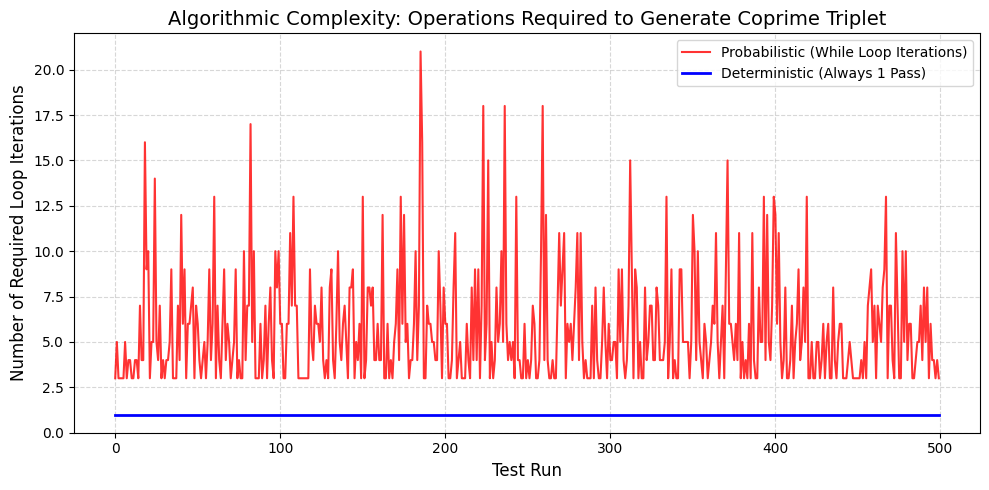

In [94]:
plt.figure(figsize=(10, 5))
plt.plot(p_iters, label='Probabilistic (While Loop Iterations)', color='red', alpha=0.8)
plt.plot(d_iters, label='Deterministic (Always 1 Pass)', color='blue', linewidth=2)

plt.title("Algorithmic Complexity: Operations Required to Generate Coprime Triplet", fontsize=14)
plt.xlabel("Test Run", fontsize=12)
plt.ylabel("Number of Required Loop Iterations", fontsize=12) 

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('Hardware-Agnostic-BEnchmark-results.png', dpi=300, bbox_inches='tight')
plt.show()